# Audit kvaliteta i oporavak transakcionih podataka: Dirty Cafe Sales

Notebook prikazuje audit kvaliteta, rule-based oporavak i analizu efekta kvaliteta podataka nad skupom `cafe_sales.csv`.


## Okvir analize

Notebook je organizovan u sest faza:

1. audit sirovog skupa,
2. klasifikacija problema u podacima,
3. rule-based oporavak,
4. poredjenje kvaliteta pre i posle oporavka,
5. EDA nad oporavljenim podacima,
6. ML eksperiment koji poredi inicijalne i oporavljene podatke.


In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
sns.set_theme(style="ticks")

INVALID_TOKENS = {"ERROR", "UNKNOWN"}
RANDOM_STATE = 42
MAX_REASONABLE_QUANTITY = 100


In [2]:
raw = pd.read_csv("./cafe_sales.csv")
raw.head()


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Receipt Modifier
0,TXN_1961373,Coffee,2,ERROR,3.60,Credit Card,Takeaway,2023-09-08,loyalty_discount
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16,none
2,TXN_4271903,Cookie,UNKNOWN,NaN,ERROR,Credit Card,In-store,UNKNOWN,none
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,ERROR,none
4,TXN_3160411,Coffee,NaN,NaN,NaN,Digital Wallet,In-store,2023-06-11,combo_discount


### Izvodjenje cenovnika iz validnih redova

Za svaki artikal posmatramo redove u kojima su `Item` i `Price Per Unit` validni, zatim kao cenu artikla uzimamo najcescu cenu. Dodatno proveravamo stabilnost cene, odnosno koliki procenat validnih redova za dati artikal ima tu dominantnu cenu.


In [3]:
price_data = raw.assign(
    Item=raw["Item"].replace(list(INVALID_TOKENS), np.nan),
    Price_num=pd.to_numeric(
        raw["Price Per Unit"].replace(list(INVALID_TOKENS), np.nan),
        errors="coerce"
    )
).dropna(subset=["Item", "Price_num"])

MENU_PRICES = (
    price_data
    .groupby("Item")["Price_num"]
    .agg(lambda prices: prices.mode().iloc[0])
    .to_dict()
)

price_check = (
    price_data
    .assign(derived_price=price_data["Item"].map(MENU_PRICES))
    .groupby("Item")
    .agg(
        derived_price=("derived_price", "first"),
        valid_rows_for_item=("Price_num", "size"),
        rows_with_derived_price=("Price_num", lambda prices: (prices == prices.mode().iloc[0]).sum()),
    )
)
price_check["price_stability_pct"] = (
    price_check["rows_with_derived_price"] / price_check["valid_rows_for_item"] * 100
).round(2)

price_check.reset_index().sort_values("Item")


,Item,derived_price,valid_rows_for_item,rows_with_derived_price,price_stability_pct
0,Cake,3.0,548,548,100.0
1,Coffee,2.0,562,562,100.0
2,Cookie,1.0,490,490,100.0
3,Juice,3.0,543,543,100.0
4,Salad,5.0,521,521,100.0
5,Sandwich,4.0,520,520,100.0
6,Smoothie,4.0,539,539,100.0
7,Tea,1.5,513,513,100.0


## Faza A: Audit sirovog skupa

U prvoj fazi proveravamo koliko je skup podataka stvarno upotrebljiv. Posebno posmatramo razliku izmedju formalno popunjenih vrednosti i vrednosti koje su validne za dalju analizu.


In [4]:
audit_overview = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "non_null": raw.notna().sum(),
    "null_pct": (raw.isna().mean() * 100).round(2),
    "unique": raw.nunique(dropna=False)
})
audit_overview


,dtype,non_null,null_pct,unique
Transaction ID,object,10000,0.00,10000
Item,object,8881,11.19,11
Quantity,object,8719,12.81,8
Price Per Unit,object,8691,13.09,9
Total Spent,object,8921,10.79,88
Payment Method,object,6933,30.67,6
Location,object,6316,36.84,5
Transaction Date,object,9177,8.23,368
Receipt Modifier,object,10000,0.00,5


In [5]:
def normalize_tokens(frame):
    df = frame.copy()
    for col in ["Item", "Quantity", "Price Per Unit", "Total Spent", "Payment Method", "Location", "Transaction Date"]:
        df[col] = df[col].replace(list(INVALID_TOKENS), np.nan)
    return df


def build_typed_view(frame):
    df = frame.copy()
    df["Quantity_num"] = pd.to_numeric(df["Quantity"], errors="coerce")
    df["Price_num"] = pd.to_numeric(df["Price Per Unit"], errors="coerce")
    df["Total_num"] = pd.to_numeric(df["Total Spent"], errors="coerce")
    df["TransactionDate_dt"] = pd.to_datetime(df["Transaction Date"], errors="coerce")
    return df


def quality_scorecard(df):
    rows = {
        "Item": df["Item"].notna().sum(),
        "Quantity": df["Quantity_num"].notna().sum(),
        "Price Per Unit": df["Price_num"].notna().sum(),
        "Total Spent": df["Total_num"].notna().sum(),
        "Payment Method": (df["Payment Method"].notna() & df["Payment Method"].ne("Unknown")).sum(),
        "Location": (df["Location"].notna() & df["Location"].ne("Unknown")).sum(),
        "Transaction Date": df["TransactionDate_dt"].notna().sum(),
    }
    out = pd.DataFrame.from_dict(rows, orient="index", columns=["usable_values"])
    out["usable_pct"] = (out["usable_values"] / len(df) * 100).round(2)
    return out


In [6]:
stage_raw = build_typed_view(normalize_tokens(raw))
scorecard_raw = quality_scorecard(stage_raw)
scorecard_raw


,usable_values,usable_pct
Item,6773,67.73
Quantity,6284,62.84
Price Per Unit,6248,62.48
Total Spent,6839,68.39
Payment Method,5458,54.58
Location,4831,48.31
Transaction Date,7632,76.32


Ovaj prikaz meri upotrebljivost kolona, a ne samo broj nepraznih vrednosti. Time se lakse uocava razlika izmedju nedostajucih podataka i nevalidnih tokena kao sto su `ERROR` i `UNKNOWN`. Kod kolona `Payment Method` i `Location`, vrednost `Unknown` se ne racuna kao stvarno upotrebljiva vrednost, vec kao eksplicitno oznacena nepoznata vrednost.


In [7]:
issue_matrix = pd.DataFrame(index=raw.columns)
issue_matrix["missing"] = raw.isna().sum()
issue_matrix["ERROR"] = raw.astype(str).eq("ERROR").sum()
issue_matrix["UNKNOWN"] = raw.astype(str).eq("UNKNOWN").sum()
issue_matrix["issue_total"] = issue_matrix.sum(axis=1)
issue_matrix.sort_values("issue_total", ascending=False)


,missing,ERROR,UNKNOWN,issue_total
Location,3684,799,686,5169
Payment Method,3067,788,687,4542
Price Per Unit,1309,1313,1130,3752
Quantity,1281,1294,1141,3716
Item,1119,1077,1031,3227
Total Spent,1079,1124,958,3161
Transaction Date,823,828,717,2368
Transaction ID,0,0,0,0
Receipt Modifier,0,0,0,0


In [8]:
print("Broj duplikata redova:", raw.duplicated().sum())
print("Broj duplikata Transaction ID:", raw["Transaction ID"].duplicated().sum())

suspicious_preview = raw[
    raw[["Item", "Quantity", "Price Per Unit", "Total Spent", "Payment Method", "Location", "Transaction Date"]]
    .astype(str)
    .apply(lambda s: s.isin(INVALID_TOKENS))
    .any(axis=1)
]
suspicious_preview.head(10)


Broj duplikata redova: 0
Broj duplikata Transaction ID: 0


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Receipt Modifier
0,TXN_1961373,Coffee,2,ERROR,3.60,Credit Card,Takeaway,2023-09-08,loyalty_discount
2,TXN_4271903,Cookie,UNKNOWN,NaN,ERROR,Credit Card,In-store,UNKNOWN,none
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,ERROR,none
5,TXN_2602893,Smoothie,5,UNKNOWN,18.00,Credit Card,NaN,2023-03-31,loyalty_discount
6,TXN_4433211,UNKNOWN,3,NaN,9.0,ERROR,ERROR,2023-10-06,service_fee
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28,none
8,TXN_4717867,NaN,5,UNKNOWN,15.0,NaN,Takeaway,ERROR,none
9,TXN_2064365,Sandwich,5,4.0,UNKNOWN,NaN,NaN,2023-12-31,none
10,TXN_2548360,Salad,ERROR,5.0,ERROR,Cash,NaN,2023-11-07,none
11,TXN_3051279,ERROR,UNKNOWN,4.0,8.0,Credit Card,Takeaway,ERROR,none


## Faza B: Taksonomija problema

U ovoj fazi grupisemo probleme po tipu: nedostajuce vrednosti, nevalidne kategorije, numericka ostecenja i odstupanja u odnosu na ocekivanu strukturu transakcije.


In [9]:
typed = stage_raw.copy()
typed["expected_price"] = typed["Item"].map(MENU_PRICES)
typed["expected_total"] = typed["Quantity_num"] * typed["Price_num"]

typed["flag_item_missing"] = typed["Item"].isna()
typed["flag_quantity_missing"] = typed["Quantity_num"].isna()
typed["flag_price_missing"] = typed["Price_num"].isna()
typed["flag_total_missing"] = typed["Total_num"].isna()
typed["flag_payment_missing"] = typed["Payment Method"].isna()
typed["flag_location_missing"] = typed["Location"].isna()
typed["flag_date_missing"] = typed["TransactionDate_dt"].isna()

typed["flag_price_conflict"] = (
    typed["Item"].isin(MENU_PRICES.keys())
    & typed["Price_num"].notna()
    & (typed["Price_num"] != typed["expected_price"])
)

typed["flag_total_conflict"] = (
    typed["Quantity_num"].notna()
    & typed["Price_num"].notna()
    & typed["Total_num"].notna()
    & (~np.isclose(typed["Total_num"], typed["expected_total"]))
)

typed[[c for c in typed.columns if c.startswith("flag_")]].sum().sort_values(ascending=False)


flag_location_missing    5169
flag_payment_missing     4542
flag_price_missing       3752
flag_quantity_missing    3716
flag_item_missing        3227
flag_total_missing       3161
flag_date_missing        2368
flag_total_conflict      1008
flag_price_conflict         0
dtype: int64

In [10]:
issue_summary = pd.Series({
    "Missing location": int(typed["flag_location_missing"].sum()),
    "Missing payment": int(typed["flag_payment_missing"].sum()),
    "Missing item": int(typed["flag_item_missing"].sum()),
    "Missing quantity": int(typed["flag_quantity_missing"].sum()),
    "Missing price": int(typed["flag_price_missing"].sum()),
    "Missing total": int(typed["flag_total_missing"].sum()),
    "Missing date": int(typed["flag_date_missing"].sum()),
    "Price conflicts": int(typed["flag_price_conflict"].sum()),
    "Total conflicts": int(typed["flag_total_conflict"].sum()),
}).sort_values()
issue_summary


Price conflicts        0
Total conflicts     1008
Missing date        2368
Missing total       3161
Missing item        3227
Missing quantity    3716
Missing price       3752
Missing payment     4542
Missing location    5169
dtype: int64

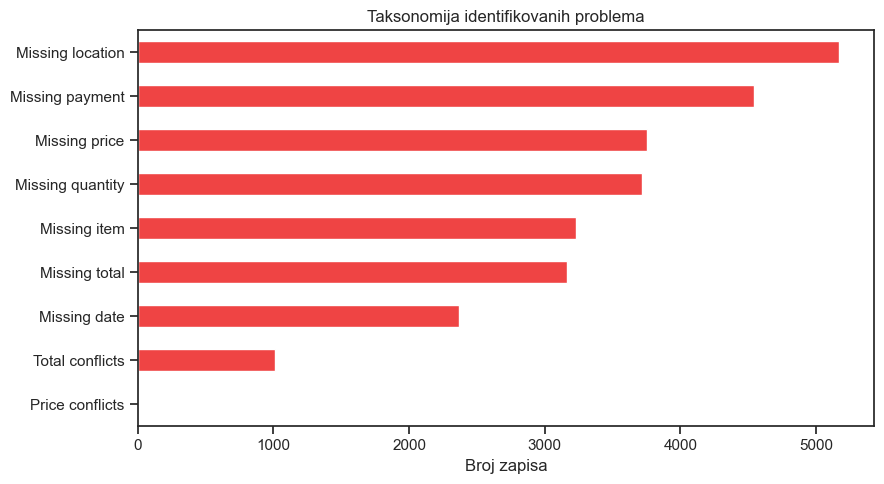

In [11]:
plt.figure(figsize=(9, 5))
issue_summary.plot(kind="barh", color="#ef4444")
plt.title("Taksonomija identifikovanih problema")
plt.xlabel("Broj zapisa")
plt.ylabel("")
plt.tight_layout()
plt.show()


U ovoj varijanti skupa kolona `Receipt Modifier` uvodi dodatni poslovni kontekst, pa odstupanje u `Total Spent` ne mora uvek znaciti gresku. Zbog toga razlikujemo ostecen zapis od legitimnog odstupanja koje nije objasnjeno samo osnovnim cenovnikom.


## Faza C: Rule engine za oporavak podataka

Oporavak zasnivamo na jednostavnim pravilima menija i aritmeticke veze izmedju kolicine, cene i ukupnog racuna. Cilj je da se popravljaju samo vrednosti koje mogu da se vrate pouzdanim pravilom.


Kod oporavka količine ne pretpostavljamo da su validne samo količine koje su već viđene u skupu. Prihvatamo svaki pozitivan celobrojni rezultat do razumnog maksimuma `MAX_REASONABLE_QUANTITY`, čime se izbegavaju nerealno velike količine, ali se ne ograničavamo samo na postojeći maksimum iz CSV fajla.


In [12]:
recovered = typed.copy()
repair_log = {}

# Price_num = MENU_PRICES[item]
mask = recovered["Price_num"].isna() & recovered["expected_price"].notna()
repair_log["price_from_item"] = int(mask.sum())
recovered.loc[mask, "Price_num"] = recovered.loc[mask, "expected_price"]

# Total_num = Quantity_num * Price_num
mask = recovered["Total_num"].isna() & recovered["Quantity_num"].notna() & recovered["Price_num"].notna()
repair_log["total_from_quantity_price"] = int(mask.sum())
recovered.loc[mask, "Total_num"] = recovered.loc[mask, "Quantity_num"] * recovered.loc[mask, "Price_num"]

# Quantity_num = Total_num / Price_num
mask = recovered["Quantity_num"].isna() & recovered["Total_num"].notna() & recovered["Price_num"].notna()
ratio = recovered.loc[mask, "Total_num"] / recovered.loc[mask, "Price_num"]
valid_ratio = (
    np.isclose(ratio, ratio.round())
    & ratio.between(1, MAX_REASONABLE_QUANTITY)
)
repair_log["quantity_from_total_price"] = int(valid_ratio.sum())
recovered.loc[ratio.index[valid_ratio], "Quantity_num"] = ratio[valid_ratio]

price_to_items = {}
for item, price in MENU_PRICES.items():
    price_to_items.setdefault(price, []).append(item)

repair_log["item_from_unique_price"] = 0

# Item = MENU_PRICES[Price_num]
mask = recovered["Item"].isna() & recovered["Price_num"].notna()
for price, items in price_to_items.items():
    if len(items) == 1:
        unique_mask = mask & (recovered["Price_num"] == price)
        repair_log["item_from_unique_price"] += int(unique_mask.sum())
        recovered.loc[unique_mask, "Item"] = items[0]

recovered["Payment Method"] = recovered["Payment Method"].fillna("Unknown")
recovered["Location"] = recovered["Location"].fillna("Unknown")
recovered["Month"] = recovered["TransactionDate_dt"].dt.month
recovered["Weekday"] = recovered["TransactionDate_dt"].dt.day_name()
recovered["Weekend"] = recovered["TransactionDate_dt"].dt.dayofweek.isin([5, 6])

repair_log


{'price_from_item': 2537,
 'total_from_quantity_price': 1741,
 'quantity_from_total_price': 1489,
 'item_from_unique_price': 1038}

In [13]:
recovery_table = pd.DataFrame.from_dict(repair_log, orient="index", columns=["recovered_rows"])
recovery_table["share_of_dataset_pct"] = (recovery_table["recovered_rows"] / len(recovered) * 100).round(2)
recovery_table.sort_values("recovered_rows", ascending=False)


,recovered_rows,share_of_dataset_pct
price_from_item,2537,25.37
total_from_quantity_price,1741,17.41
quantity_from_total_price,1489,14.89
item_from_unique_price,1038,10.38


Kolone `Payment Method` i `Location` ne oporavljamo stvarnim vrednostima, jer za njih nemamo pouzdano pravilo. Umesto toga, nedostajuce vrednosti samo standardizujemo kao `Unknown`, kako bi ogranicenje podataka ostalo vidljivo.


In [14]:
standardization_table = pd.DataFrame({
    "standardized_as_unknown": {
        "Payment Method": int(typed["Payment Method"].isna().sum()),
        "Location": int(typed["Location"].isna().sum()),
    }
})
standardization_table["share_of_dataset_pct"] = (
    standardization_table["standardized_as_unknown"] / len(typed) * 100
).round(2)
standardization_table


,standardized_as_unknown,share_of_dataset_pct
Payment Method,4542,45.42
Location,5169,51.69


Rule-based pristup smanjuje rizik od proizvoljne imputacije i zadrzava znacenje transakcije tamo gde je oporavak opravdan.


In [15]:
scorecard_recovered = quality_scorecard(recovered)
comparison = scorecard_raw.join(scorecard_recovered, lsuffix="_before", rsuffix="_after")
comparison["gain_values"] = comparison["usable_values_after"] - comparison["usable_values_before"]
comparison["gain_pct_points"] = (comparison["usable_pct_after"] - comparison["usable_pct_before"]).round(2)
comparison


,usable_values_before,usable_pct_before,usable_values_after,usable_pct_after,gain_values,gain_pct_points
Item,6773,67.73,7811,78.11,1038,10.38
Quantity,6284,62.84,7773,77.73,1489,14.89
Price Per Unit,6248,62.48,8785,87.85,2537,25.37
Total Spent,6839,68.39,8580,85.80,1741,17.41
Payment Method,5458,54.58,5458,54.58,0,0.00
Location,4831,48.31,4831,48.31,0,0.00
Transaction Date,7632,76.32,7632,76.32,0,0.00


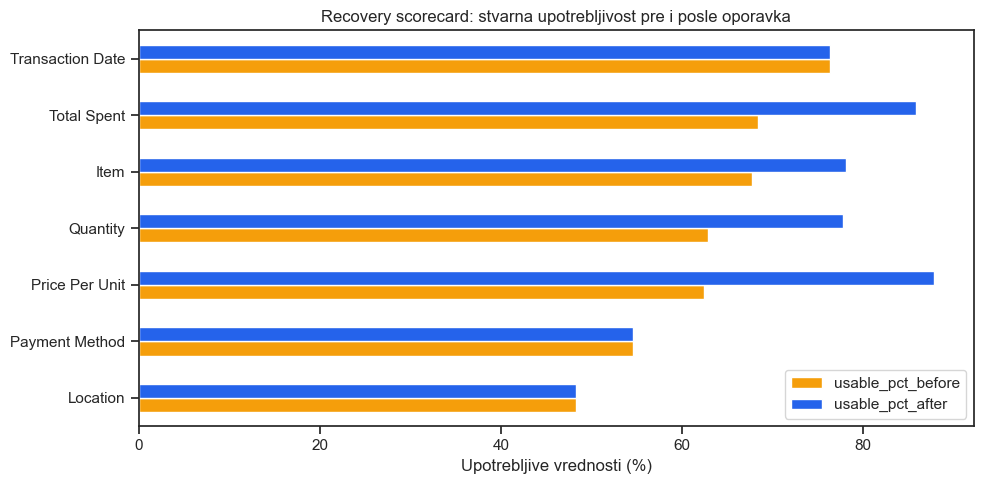

In [16]:
plot_df = comparison[["usable_pct_before", "usable_pct_after"]].sort_values("usable_pct_before")
plot_df.plot(kind="barh", figsize=(10, 5), color=["#f59e0b", "#2563eb"])
plt.title("Recovery scorecard: stvarna upotrebljivost pre i posle oporavka")
plt.xlabel("Upotrebljive vrednosti (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()


Posle ove izmene grafikon prikazuje stvarnu upotrebljivost, a ne samo formalnu popunjenost. Zato `Payment Method` i `Location` ne skacu na 100%: vrednosti oznacene kao `Unknown` ostaju transparentno prisutne u podacima, ali se ne tretiraju kao oporavljena informacija.


## Faza D: Sloj pouzdanosti zapisa

Posle oporavka uvodimo jednostavan nivo poverenja po redu kako bismo razlikovali zapise visoke, srednje i niske pouzdanosti.


In [17]:
recovered["known_core_fields"] = recovered[["Item", "Quantity_num", "Price_num", "Total_num"]].notna().sum(axis=1)

conditions = [
    (recovered["known_core_fields"] == 4) & recovered["TransactionDate_dt"].notna(),
    (recovered["known_core_fields"] >= 3),
]
choices = ["high", "medium"]
recovered["trust_tier"] = np.select(conditions, choices, default="low")

trust_summary = pd.DataFrame({
    "rows": recovered["trust_tier"].value_counts(),
    "pct": (recovered["trust_tier"].value_counts(normalize=True) * 100).round(2)
})
trust_summary


,rows,pct
trust_tier,,
high,4736,47.36
medium,2950,29.50
low,2314,23.14


In [18]:
recovered["revenue_known"] = recovered["Total_num"].notna()
coverage_table = pd.DataFrame({
    "count": recovered.groupby("trust_tier")["revenue_known"].size(),
    "revenue_available_pct": (recovered.groupby("trust_tier")["revenue_known"].mean() * 100).round(2)
})
coverage_table


,count,revenue_available_pct
trust_tier,,
high,4736,100.00
low,2314,38.63
medium,2950,100.00


Ovaj sloj olaksava dalju analizu jer omogucava da se izvestaji i modeli grade nad pouzdanijim delom skupa.


## Faza E: EDA nad oporavljenim podacima

Poslovnu analizu radimo nad oporavljenim podacima kako bi zakljucci bili zasnovani na stabilnijem i upotrebljivijem skupu.


In [19]:
revenue_by_item = (
    recovered.dropna(subset=["Item", "Total_num"])
    .groupby("Item")
    .agg(
        transactions=("Transaction ID", "count"),
        total_revenue=("Total_num", "sum"),
        avg_ticket=("Total_num", "mean")
    )
    .sort_values("total_revenue", ascending=False)
)
revenue_by_item


,transactions,total_revenue,avg_ticket
Item,,,
Salad,974,14445.75,14.831366
Sandwich,760,9324.40,12.268947
Smoothie,736,9068.00,12.320652
Juice,763,6991.05,9.162582
Cake,761,6868.95,9.026216
Coffee,988,6039.10,6.112449
Tea,941,4269.56,4.537258
Cookie,964,2864.35,2.971317


In [20]:
channel_mix = pd.crosstab(recovered["Location"], recovered["Payment Method"], normalize="index").round(3)
channel_mix


Payment Method,Cash,Credit Card,Digital Wallet,Unknown
Location,,,,
In-store,0.197,0.179,0.188,0.435
Takeaway,0.173,0.183,0.206,0.439
Unknown,0.176,0.182,0.172,0.470


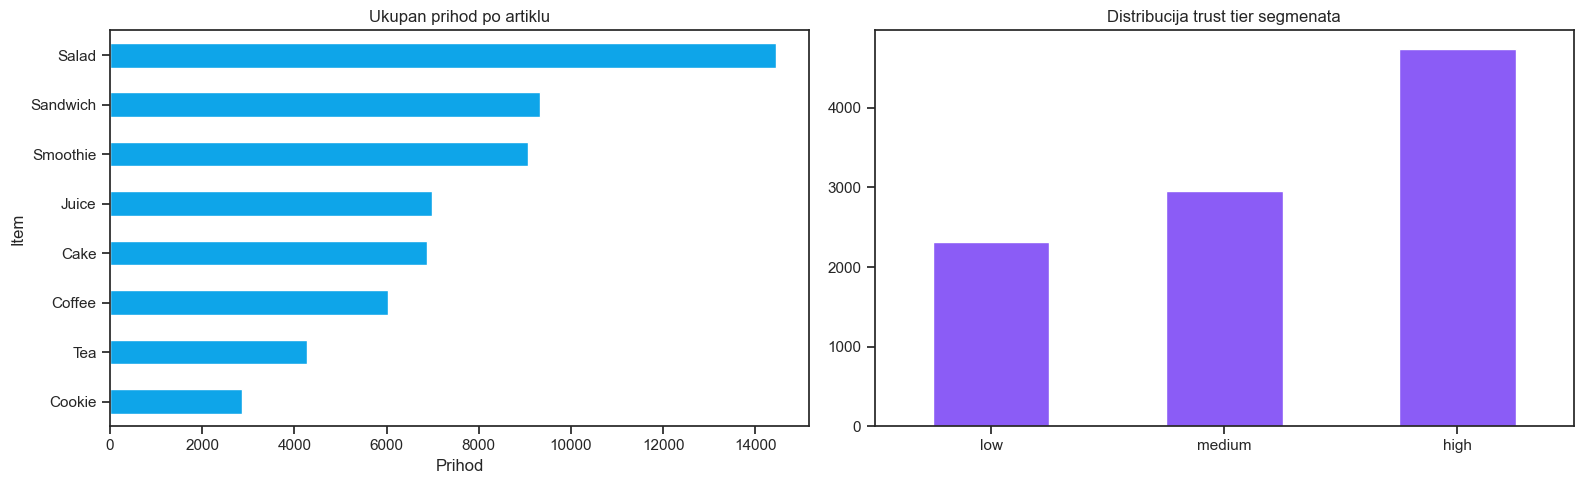

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

revenue_by_item["total_revenue"].sort_values().plot(kind="barh", ax=axes[0], color="#0ea5e9")
axes[0].set_title("Ukupan prihod po artiklu")
axes[0].set_xlabel("Prihod")

trust_summary.loc[["low", "medium", "high"], "rows"].plot(kind="bar", ax=axes[1], color="#8b5cf6")
axes[1].set_title("Distribucija trust tier segmenata")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


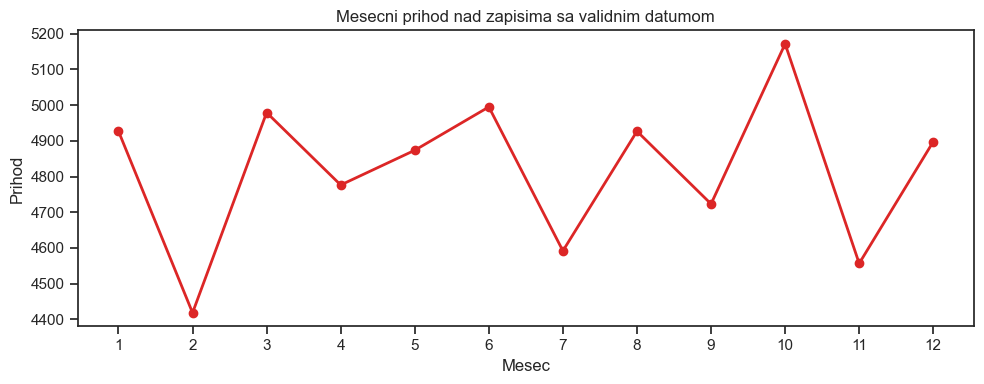

In [22]:
monthly_revenue = (
    recovered.dropna(subset=["Month", "Total_num"])
    .groupby("Month")["Total_num"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(10, 4))
monthly_revenue.plot(marker="o", linewidth=2, color="#dc2626")
plt.title("Mesecni prihod nad zapisima sa validnim datumom")
plt.xlabel("Mesec")
plt.ylabel("Prihod")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()


## Faza E2: Raspodela, varijansa i korelacija

Pošto je tema rada kvalitet podataka, pored mera potpunosti i validnosti potrebno je analizirati i statističke osobine numeričkih atributa. U ovoj fazi posmatramo raspodelu, varijansu, standardnu devijaciju i korelacije za ključne numeričke kolone nakon oporavka podataka.


In [23]:
numeric_quality_cols = ["Quantity_num", "Price_num", "Total_num", "Month"]

distribution_summary = recovered[numeric_quality_cols].describe().T
variance_summary = recovered[numeric_quality_cols].agg(["var", "std", "mean", "median", "min", "max"]).T.round(3)
variance_summary


,var,std,mean,median,min,max
Quantity_num,2.009,1.417,3.036,3.0,1.00,5.00
Price_num,1.637,1.279,2.949,3.0,1.00,5.00
Total_num,36.084,6.007,8.885,7.5,0.85,28.75
Month,11.979,3.461,6.498,6.0,1.00,12.00


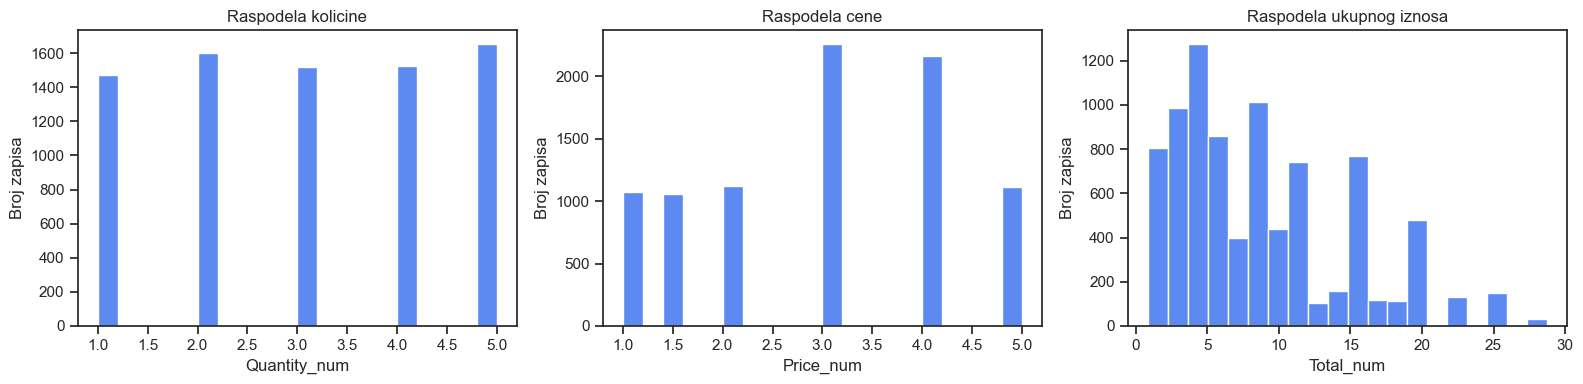

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, title in zip(
    axes,
    ["Quantity_num", "Price_num", "Total_num"],
    ["Raspodela kolicine", "Raspodela cene", "Raspodela ukupnog iznosa"],
):
    sns.histplot(recovered[col].dropna(), bins=20, kde=False, ax=ax, color="#2563eb")
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Broj zapisa")

plt.tight_layout()
plt.show()


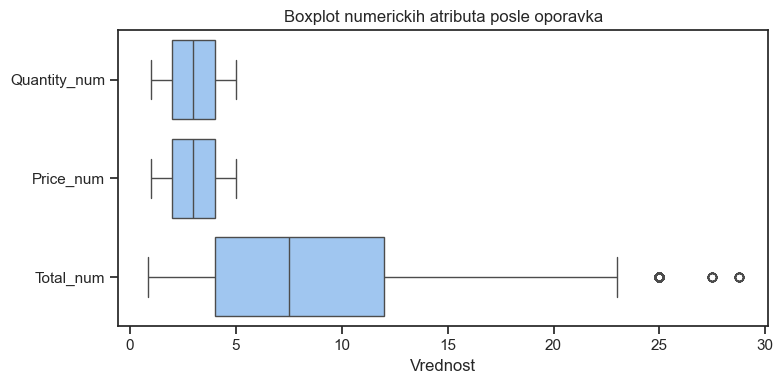

In [25]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=recovered[["Quantity_num", "Price_num", "Total_num"]], orient="h", color="#93c5fd")
plt.title("Boxplot numerickih atributa posle oporavka")
plt.xlabel("Vrednost")
plt.tight_layout()
plt.show()


In [26]:
correlation_frame = recovered[["Quantity_num", "Price_num", "Total_num", "Month", "Weekend"]].copy()
correlation_frame["Weekend"] = correlation_frame["Weekend"].astype(float)
correlation_matrix = correlation_frame.corr(numeric_only=True).round(3)
correlation_matrix


,Quantity_num,Price_num,Total_num,Month,Weekend
Quantity_num,1.000,0.000,0.694,-0.000,-0.009
Price_num,0.000,1.000,0.641,-0.021,-0.006
Total_num,0.694,0.641,1.000,-0.005,-0.010
Month,-0.000,-0.021,-0.005,1.000,0.016
Weekend,-0.009,-0.006,-0.010,0.016,1.000


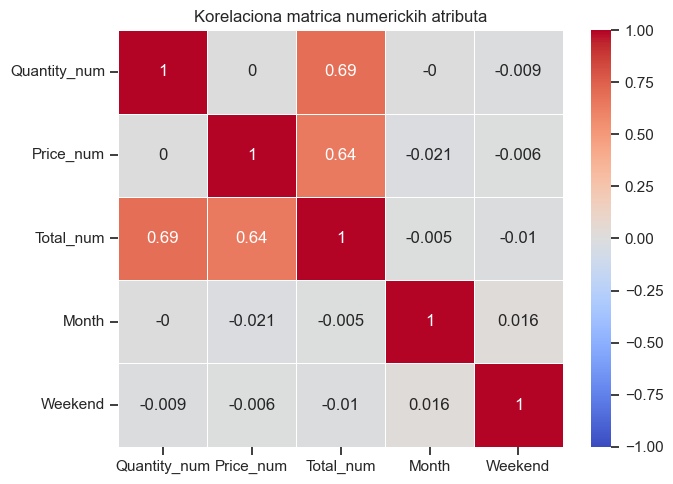

In [27]:
plt.figure(figsize=(7, 5))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Korelaciona matrica numerickih atributa")
plt.tight_layout()
plt.show()


Raspodele i boxplot prikazi pomažu da se uoče rasponi, tipične vrednosti i eventualna odstupanja numeričkih atributa. Tabela varijanse i standardne devijacije pokazuje koliko su vrednosti rasute oko proseka, dok korelaciona matrica prikazuje linearnu povezanost između količine, cene, ukupnog iznosa i vremenskih atributa. Ove metrike dopunjuju audit kvaliteta jer ne govore samo o tome da li vrednost postoji, već i o tome kakva je struktura podataka koji ostaju za analizu.


## Faza F: Poređenje modela nad inicijalnim i oporavljenim podacima

U završnoj fazi merimo kako kvalitet podataka utiče na model kroz direktno poređenje dve verzije istog realnog skupa:

- `initial_raw_data`: inicijalni skup nakon osnovnog parsiranja tokena, bez rule-based oporavka,
- `recovered_dataset_data`: isti skup nakon primene pravila oporavka.

Ciljna promenljiva je `ticket_band`, odnosno kategorija vrednosti računa. Da bi poređenje bilo fer, svi modeli koriste iste transakcije i istu train-test podelu. Na taj način se poredi efekat kvaliteta ulaznih atributa, a ne promena uzorka podataka.


In [28]:
def add_time_features(frame):
    df = frame.copy()
    df["Month"] = df["TransactionDate_dt"].dt.month
    df["Weekday"] = df["TransactionDate_dt"].dt.day_name()
    df["WeekendFlag"] = pd.Series(np.nan, index=df.index, dtype="object")
    dated = df["TransactionDate_dt"].notna()
    weekend = df["TransactionDate_dt"].dt.dayofweek.isin([5, 6])
    df.loc[dated, "WeekendFlag"] = np.where(weekend[dated], "Weekend", "Workday")
    return df


model_target = recovered.loc[
    recovered["Total_num"].notna(),
    ["Transaction ID", "Total_num"]
].copy()
model_target["ticket_band"] = pd.qcut(
    model_target["Total_num"],
    q=3,
    labels=["low", "medium", "high"]
)

ticket_band_by_id = model_target.set_index("Transaction ID")["ticket_band"]
model_ids = model_target["Transaction ID"]

initial_raw_data = add_time_features(
    stage_raw[stage_raw["Transaction ID"].isin(model_ids)].copy()
)
initial_raw_data["ticket_band"] = initial_raw_data["Transaction ID"].map(ticket_band_by_id)

recovered_dataset_data = add_time_features(
    recovered[recovered["Transaction ID"].isin(model_ids)].copy()
)
recovered_dataset_data["ticket_band"] = recovered_dataset_data["Transaction ID"].map(ticket_band_by_id)

pd.DataFrame({
    "rows": {
        "initial_raw_data": len(initial_raw_data),
        "recovered_dataset_data": len(recovered_dataset_data),
    },
    "target_available_pct": {
        "initial_raw_data": round(initial_raw_data["ticket_band"].notna().mean() * 100, 2),
        "recovered_dataset_data": round(recovered_dataset_data["ticket_band"].notna().mean() * 100, 2),
    }
})


,rows,target_available_pct
initial_raw_data,8580,100.0
recovered_dataset_data,8580,100.0


In [29]:
feature_cols = [
    "Item",
    "Quantity_num",
    "Price_num",
    "Payment Method",
    "Location",
    "Month",
    "Weekday",
    "WeekendFlag",
]
numeric_features = ["Quantity_num", "Price_num", "Month"]
categorical_features = ["Item", "Payment Method", "Location", "Weekday", "WeekendFlag"]

split_frame = model_target[["Transaction ID", "ticket_band"]].drop_duplicates()
train_ids, test_ids = train_test_split(
    split_frame["Transaction ID"],
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=split_frame["ticket_band"],
)

model_configs = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(
        n_estimators=350,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=350,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=250,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=RANDOM_STATE,
    ),
}


def effective_feature_completeness(frame):
    effective = frame[feature_cols].copy()
    for col in ["Payment Method", "Location"]:
        effective[col] = effective[col].replace("Unknown", np.nan)
    return round((1 - effective.isna().mean().mean()) * 100, 2)


def build_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_features),
            (
                "cat",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("encoder", OneHotEncoder(handle_unknown="ignore")),
                    ]
                ),
                categorical_features,
            ),
        ],
        sparse_threshold=0.0,
    )


def run_ticket_experiment(frame, dataset_label, model_name, classifier):
    train = frame[frame["Transaction ID"].isin(train_ids)].copy()
    test = frame[frame["Transaction ID"].isin(test_ids)].copy()

    model = Pipeline(
        steps=[
            ("preprocessor", build_preprocessor()),
            ("classifier", classifier),
        ]
    )

    X_train = train[feature_cols]
    X_test = test[feature_cols]
    y_train = train["ticket_band"]
    y_test = test["ticket_band"]

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    report = pd.DataFrame(
        classification_report(y_test, pred, output_dict=True)
    ).T.round(3)

    return {
        "model": model_name,
        "dataset": dataset_label,
        "rows": len(frame),
        "train_rows": len(train),
        "test_rows": len(test),
        "effective_feature_completeness_pct": effective_feature_completeness(frame),
        "accuracy": round(accuracy_score(y_test, pred), 4),
        "macro_f1": round(f1_score(y_test, pred, average="macro"), 4),
        "report": report,
    }


In [30]:
all_results = []
for model_name, classifier in model_configs.items():
    all_results.append(
        run_ticket_experiment(initial_raw_data, "initial_raw_data", model_name, classifier)
    )
    all_results.append(
        run_ticket_experiment(recovered_dataset_data, "recovered_dataset_data", model_name, classifier)
    )

experiment_summary = (
    pd.DataFrame(all_results)
    .drop(columns=["report"])
    .set_index(["model", "dataset"])
    .sort_index()
)
display(experiment_summary)

metric_pivot = experiment_summary.reset_index().pivot(
    index="model",
    columns="dataset",
    values="macro_f1",
)
metric_pivot["macro_f1_gain"] = (
    metric_pivot["recovered_dataset_data"] - metric_pivot["initial_raw_data"]
).round(4)
display(metric_pivot.sort_values("recovered_dataset_data", ascending=False))


rows  train_rows  test_rows  effective_feature_completeness_pct  accuracy  macro_f1
model                dataset                                                                                                    
ExtraTrees           initial_raw_data        8580        6435       2145                               67.02    0.8177    0.8163
                     recovered_dataset_data  8580        6435       2145                               73.79    0.9063    0.9051
HistGradientBoosting initial_raw_data        8580        6435       2145                               67.02    0.8270    0.8261
                     recovered_dataset_data  8580        6435       2145                               73.79    0.9026    0.9015
LogisticRegression   initial_raw_data        8580        6435       2145                               67.02    0.7702    0.7675
                     recovered_dataset_data  8580        6435       2145                               73.79    0.9021    0.9004
RandomForest         initial_raw_data        8580        6435       2145                               67.02    0.8298    0.8285
                     recovered_dataset_data  8580        6435       2145                               73.79    0.9166    0.9156

dataset,initial_raw_data,recovered_dataset_data,macro_f1_gain
model,,,
RandomForest,0.8285,0.9156,0.0871
ExtraTrees,0.8163,0.9051,0.0888
HistGradientBoosting,0.8261,0.9015,0.0754
LogisticRegression,0.7675,0.9004,0.1329


In [31]:
best_model_name = metric_pivot["recovered_dataset_data"].idxmax()
initial_best_report = next(
    result["report"] for result in all_results
    if result["model"] == best_model_name and result["dataset"] == "initial_raw_data"
)
recovered_best_report = next(
    result["report"] for result in all_results
    if result["model"] == best_model_name and result["dataset"] == "recovered_dataset_data"
)

print("Najbolji model nad oporavljenim podacima:", best_model_name)
report_compare = pd.concat(
    {
        "initial_raw_data": initial_best_report,
        "recovered_dataset_data": recovered_best_report,
    },
    axis=1,
)
display(report_compare.loc[["low", "medium", "high", "accuracy", "macro avg"]])


Najbolji model nad oporavljenim podacima: RandomForest


initial_raw_data                          recovered_dataset_data                          
                 precision recall f1-score  support              precision recall f1-score   support
low                  0.915  0.817    0.863   766.00                  0.960  0.918    0.939   766.000
medium               0.790  0.777    0.784   673.00                  0.885  0.890    0.887   673.000
high                 0.790  0.894    0.839   706.00                  0.902  0.941    0.921   706.000
accuracy             0.830  0.830    0.830     0.83                  0.917  0.917    0.917     0.917
macro avg            0.832  0.829    0.829  2145.00                  0.916  0.916    0.916  2145.000

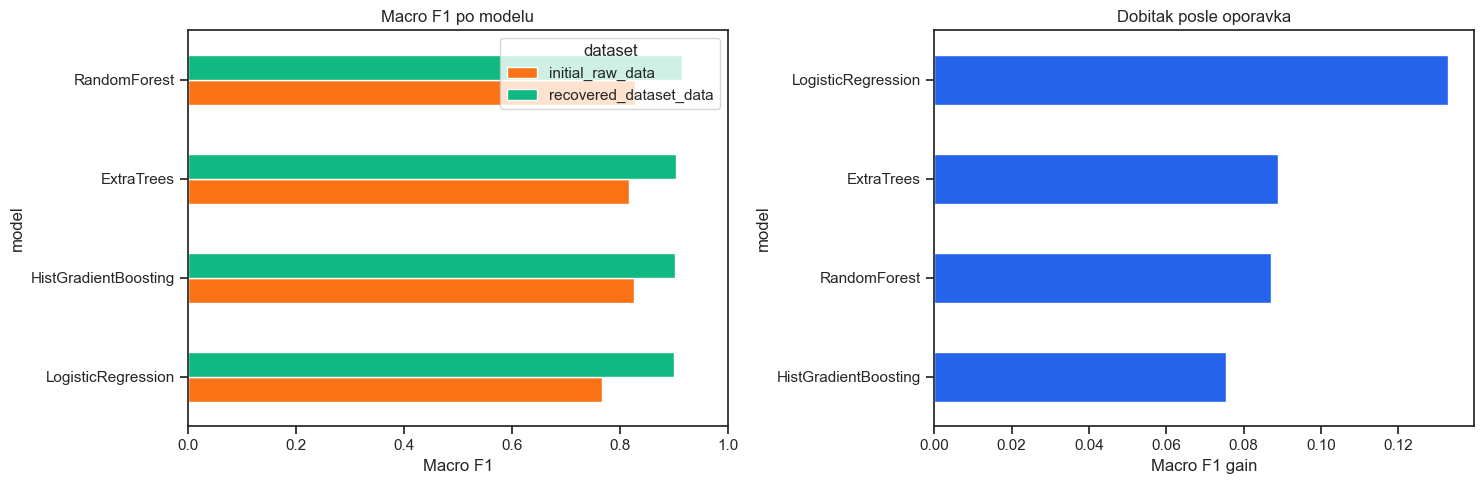

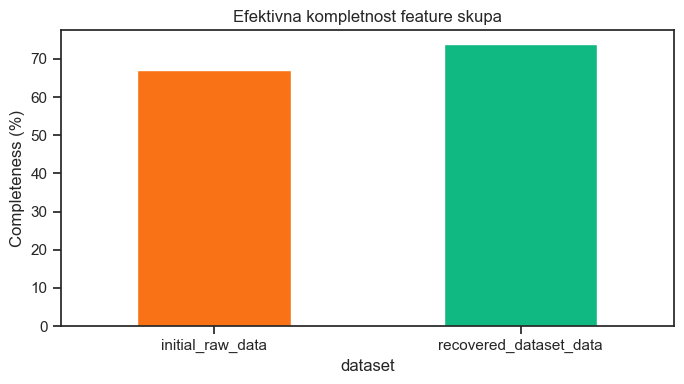

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

metric_pivot[["initial_raw_data", "recovered_dataset_data"]].sort_values(
    "recovered_dataset_data"
).plot(kind="barh", ax=axes[0], color=["#f97316", "#10b981"])
axes[0].set_title("Macro F1 po modelu")
axes[0].set_xlabel("Macro F1")
axes[0].set_xlim(0, 1)

metric_pivot["macro_f1_gain"].sort_values().plot(kind="barh", ax=axes[1], color="#2563eb")
axes[1].set_title("Dobitak posle oporavka")
axes[1].set_xlabel("Macro F1 gain")

plt.tight_layout()
plt.show()

completeness_by_dataset = experiment_summary.reset_index().drop_duplicates("dataset").set_index("dataset")[
    "effective_feature_completeness_pct"
]
completeness_by_dataset.plot(kind="bar", figsize=(7, 4), color=["#f97316", "#10b981"])
plt.title("Efektivna kompletnost feature skupa")
plt.ylabel("Completeness (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Ovaj eksperiment prikazuje praktičnu razliku između rada nad inicijalnim podacima i rada nad istim podacima nakon rule-based oporavka. Pošto se isti obrazac poboljšanja proverava kroz više modela, zaključak nije vezan samo za jedan algoritam. Poboljšanje metrika ne znači da je skup postao savršen, već da su oporavljene vrednosti u ključnim kolonama omogućile modelima stabilniji ulaz.


## Zakljucak

Projekat prikazuje kompletan tok rada nad problemom kvaliteta podataka: audit, klasifikaciju problema, rule-based oporavak, procenu pouzdanosti zapisa i proveru efekta nad modelom masinskog ucenja.

Glavni nalazi su sledeci:

- skup sadrzi veliki broj nevalidnih i nedostajucih vrednosti,
- cenovnik je izveden iz validnih redova u CSV fajlu, a ne proizvoljno zadat,
- pravila zasnovana na meniju i aritmetici omogucavaju oporavak dela zapisa,
- `Payment Method` i `Location` nisu prikazani kao oporavljeni kada su samo oznaceni kao `Unknown`,
- `trust_tier` sloj pomaze da se izdvoje pouzdaniji zapisi,
- vise modela nad oporavljenim podacima pokazuje bolju performansu nego nad inicijalnim podacima.
